In [1]:
import os 
os.chdir('../../')

In [2]:
print('done')

done


In [3]:
from backbones.pixart_alpha import PixArtAlpha

# 사용 예
model = PixArtAlpha()
print(model)

2025-09-17 11:05:59.088748: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of the model checkpoint at /home/scpark/.cache/huggingface/hub/models--PixArt-alpha--PixArt-XL-2-512x512/snapshots/50f702106901db6d0f8b67eb88e814c56ded2692/transformer were not used when initializing PixArtTransformer2DModel: 
 ['caption_projection.y_embedding']


In [6]:
import matplotlib.pyplot as plt

def show_compare(euler_img, dpm_img, unipc_img):
    fig, axes = plt.subplots(1, 3, figsize=(18, 10))
    axes[0].imshow(euler_img); axes[0].axis('off'); axes[0].set_title('Euler')
    axes[1].imshow(dpm_img);  axes[1].axis('off'); axes[1].set_title('DPM-Solver')
    axes[2].imshow(unipc_img);  axes[2].axis('off'); axes[2].set_title('UniPC')
    plt.tight_layout()
    plt.show()


torch.Size([1, 4, 64, 64])


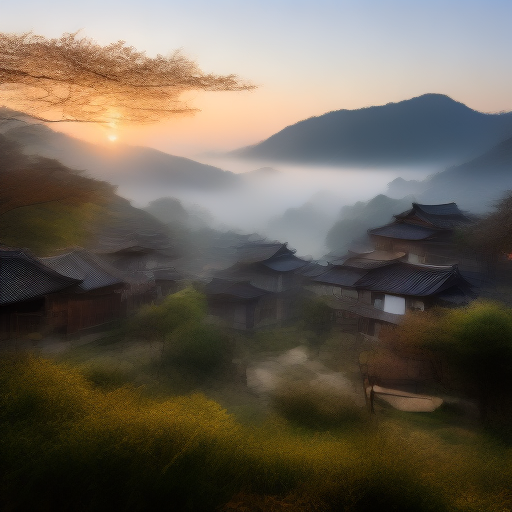

In [7]:
from solvers.others.euler_solver import Euler_Solver

pos_texts = ["A serene twilight view of a traditional Korean hanok village nestled between misty mountain slopes: "]
neg_texts = ["lowres, bad anatomy, deformed, blurry, pixelated, oversaturated, underexposed, overexposed, artifact, "]

noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=pos_texts, neg_conds=neg_texts, guidance_scale=3.5)
latents = model.get_noise(seeds=[0])
print(latents.shape)

NFE = 5
solver = Euler_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
euler_latents = solver.sample(latents, model_fn)['samples']
euler_samples = model.decode_vae(euler_latents, pil_output=True)
euler_samples['pil_output'][0]
